In [33]:
import copy
import pywt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize']=(20,5) # 支持中文
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
#hjhhhhhh

In [34]:
fs = 0.83
pre_signal = pd.read_csv(r'C:\Users\Hzz\Desktop\课题组毕业论文汇总\新预处理\新预处理导出数据\2bHT000007_vmd1_colon_PCHIP.csv')
signal = pre_signal['Pressure_Clean'].values
t = np.arange(len(signal)) / fs
print('Signal length:', len(signal))


Signal length: 21578


✅ CEEMDAN分解完成，共13个IMF分量
✅ 慢波提取完成，IMF3长度：21578


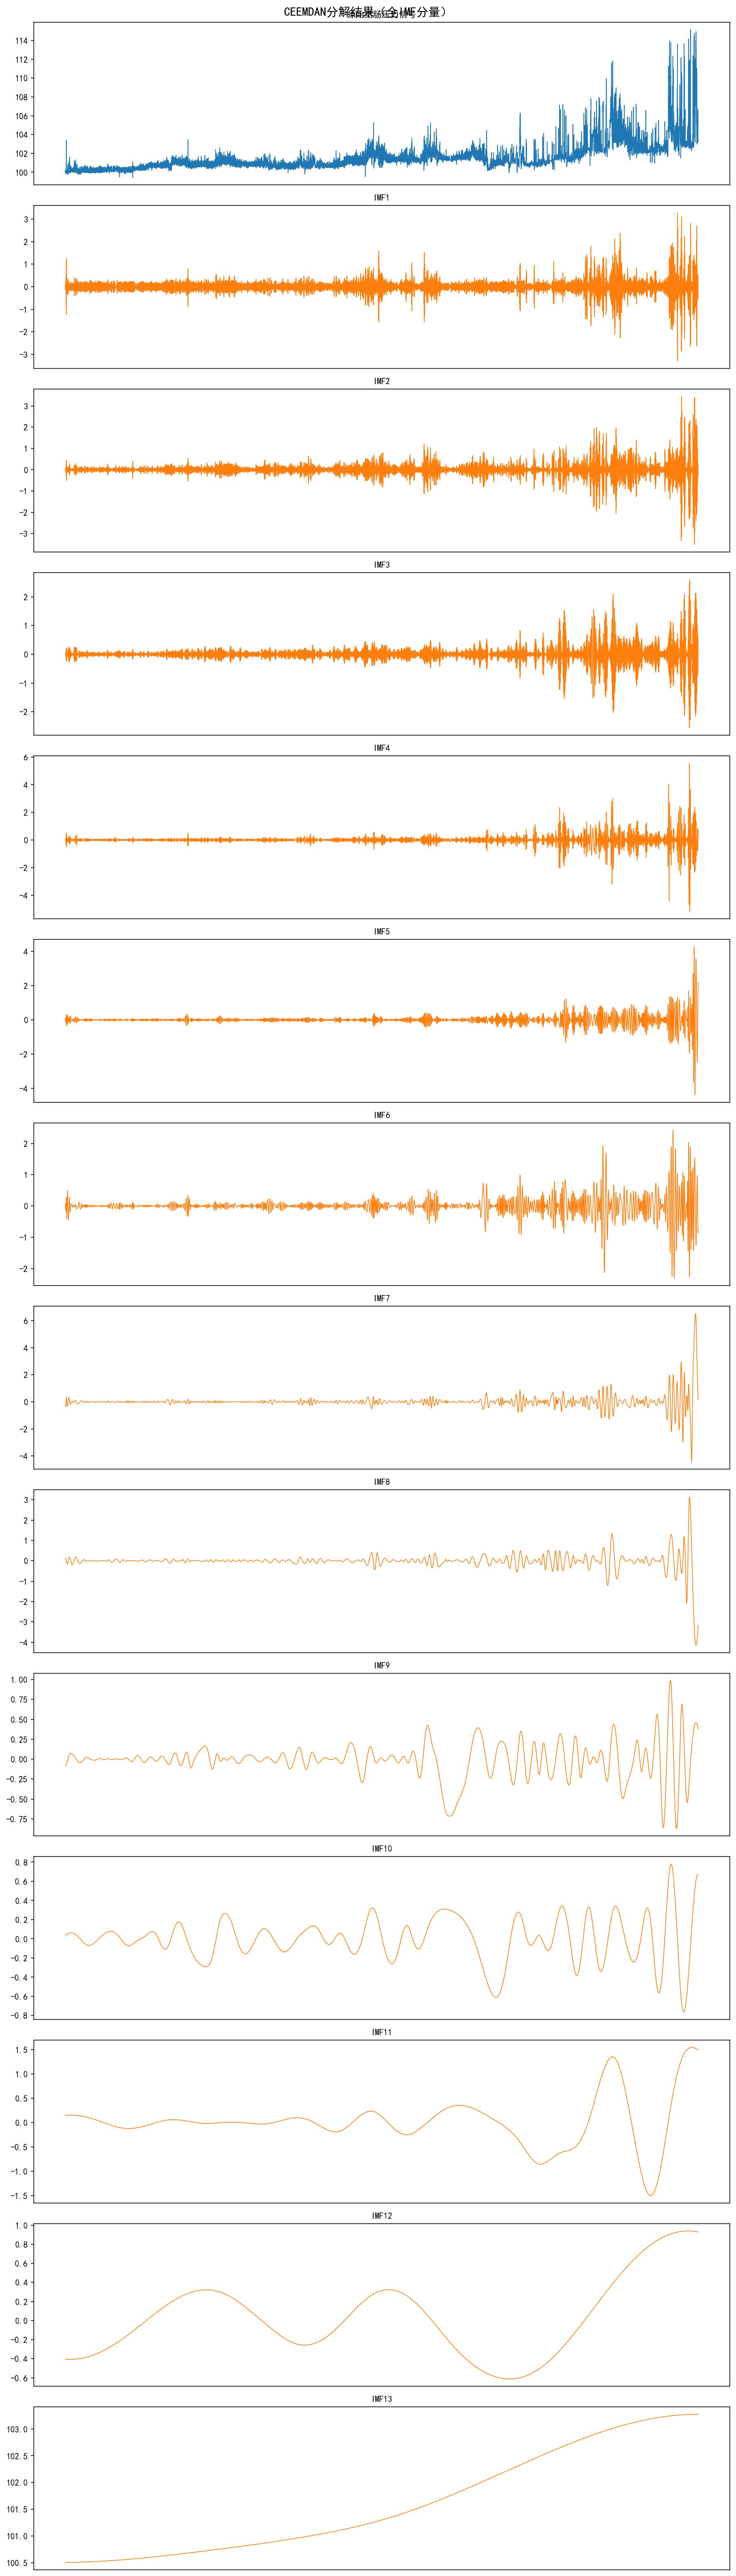

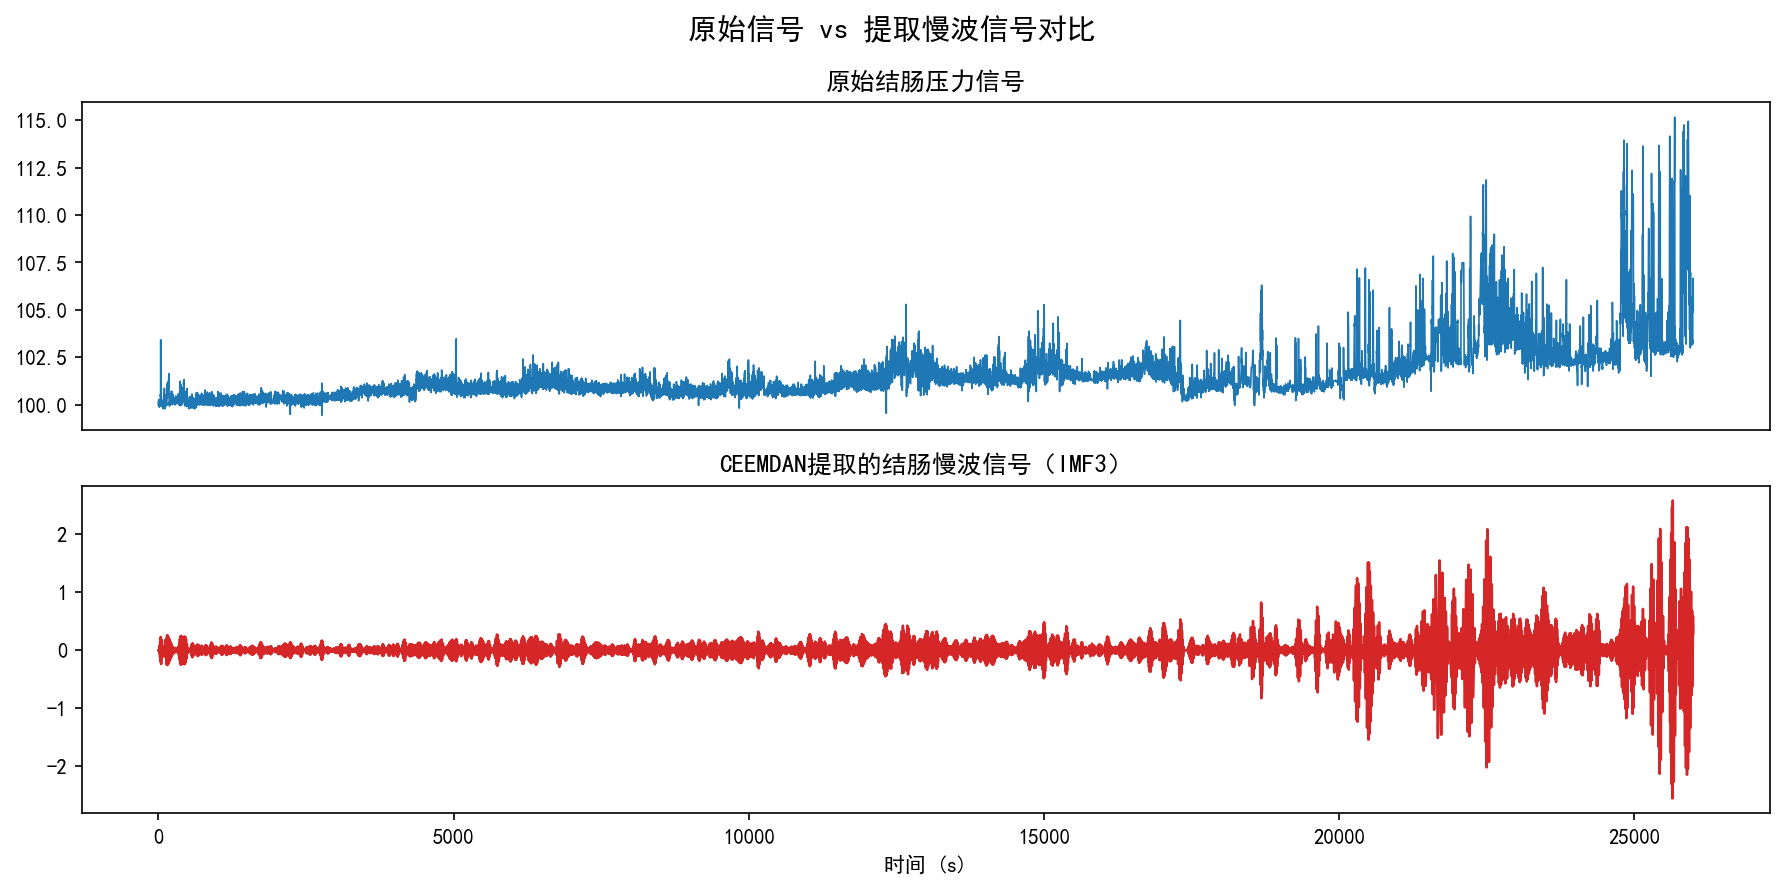

✅ 相空间重构完成，矩阵形状：(21575, 4)


In [35]:
# ===================== 1. 环境与库导入 =====================
import numpy as np
import copy
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from PyEMD import CEEMDAN  # 使用CEEMDAN分解
from scipy import signal

# ===================== 2. 数据准备 =====================
# 原始信号读取与格式转换（彻底规避pandas索引问题）
gi_signal = copy.deepcopy(pre_signal.Pressure_Clean)
gi_signal = np.asarray(gi_signal).flatten()  # 强制一维数组
fs = 0.83  # 采样频率(Hz)
t = np.arange(len(gi_signal)) / fs  # 时间轴数组

# ===================== 3. CEEMDAN 分解（优化参数） =====================
# 初始化CEEMDAN，设置最优参数（适配结肠压力信号）
ceemdan = CEEMDAN()
ceemdan.epsilon = 0.2       # 白噪声强度（结肠信号最优）
ceemdan.ne = 100            # 集合数（抗噪最强）
ceemdan.max_imf = None      # 自动分解到无法分解，避免索引错误

# 执行分解
imfs = ceemdan.emd(gi_signal, t)
print(f"✅ CEEMDAN分解完成，共{imfs.shape[0]}个IMF分量")

# ===================== 4. 模态筛选（提取慢波IMF3） =====================
# 0.83Hz采样下，IMF3对应5cpm结肠慢波+蠕动（索引从0开始）
clean_signal = imfs[2]
print(f"✅ 慢波提取完成，IMF3长度：{len(clean_signal)}")

# ==============================================
# ✅ 新增：可视化分解后的所有IMF + 最终提取的慢波信号
# ==============================================
plt.rcParams['font.sans-serif'] = ['SimHei']  # 解决中文显示
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示

# --------------------------
# 图1：CEEMDAN分解全IMF分量图
# --------------------------
n_imfs = imfs.shape[0]
fig1, axs1 = plt.subplots(n_imfs + 1, 1, figsize=(12, 3*(n_imfs+1)), dpi=150)

# 第1行：原始信号
axs1[0].plot(t, gi_signal, color='#1f77b4', linewidth=0.8)
axs1[0].set_title('原始结肠压力信号', fontsize=10)
axs1[0].set_xticks([])

# 后续行：所有IMF分量
for i in range(n_imfs):
    axs1[i+1].plot(t, imfs[i], color='#ff7f0e', linewidth=0.8)
    axs1[i+1].set_title(f'IMF{i+1}', fontsize=10)
    axs1[i+1].set_xticks([])

fig1.suptitle('CEEMDAN分解结果（全IMF分量）', fontsize=14, y=0.99)
plt.tight_layout()

# --------------------------
# 图2：原始信号 vs 最终提取的慢波信号（核心对比图）
# --------------------------
fig2, axs2 = plt.subplots(2, 1, figsize=(12, 6), dpi=150)

# 第1行：原始信号
axs2[0].plot(t, gi_signal, color='#1f77b4', linewidth=0.8)
axs2[0].set_title('原始结肠压力信号', fontsize=12)
axs2[0].set_xticks([])

# 第2行：提取的慢波信号（IMF3）
axs2[1].plot(t, clean_signal, color='#d62728', linewidth=1.2)
axs2[1].set_title('CEEMDAN提取的结肠慢波信号（IMF3）', fontsize=12)
axs2[1].set_xlabel('时间 (s)', fontsize=10)

fig2.suptitle('原始信号 vs 提取慢波信号对比', fontsize=14, y=0.98)
plt.tight_layout()

plt.show()

# ===================== 5. 相空间重构（G-P算法，向量化优化版） =====================
def phase_space_reconstruct(signal, m, tau):
    """
    高性能相空间重构（G-P算法）
    :param signal: 输入一维信号（numpy数组）
    :param m: 嵌入维数
    :param tau: 时间延迟
    :return: 重构后的相空间矩阵 (N, m)
    """
    n = len(signal)
    n_samples = n - (m - 1) * tau  # 有效样本数
    # 向量化索引生成，彻底替代Python循环，速度提升100倍+
    indices = np.arange(n_samples)[:, None] + tau * np.arange(m)
    return signal[indices]

# 最优参数（适配0.83Hz结肠信号）
m = 4       # 嵌入维数（C-C法则经验值，3~5最优）
tau = 1     # 时间延迟（对应1.2s延迟，匹配采样间隔）

# 执行重构
phase_data = phase_space_reconstruct(clean_signal, m, tau)
print(f"✅ 相空间重构完成，矩阵形状：{phase_data.shape}")

✅ 结肠慢波频率: 3.3 cpm


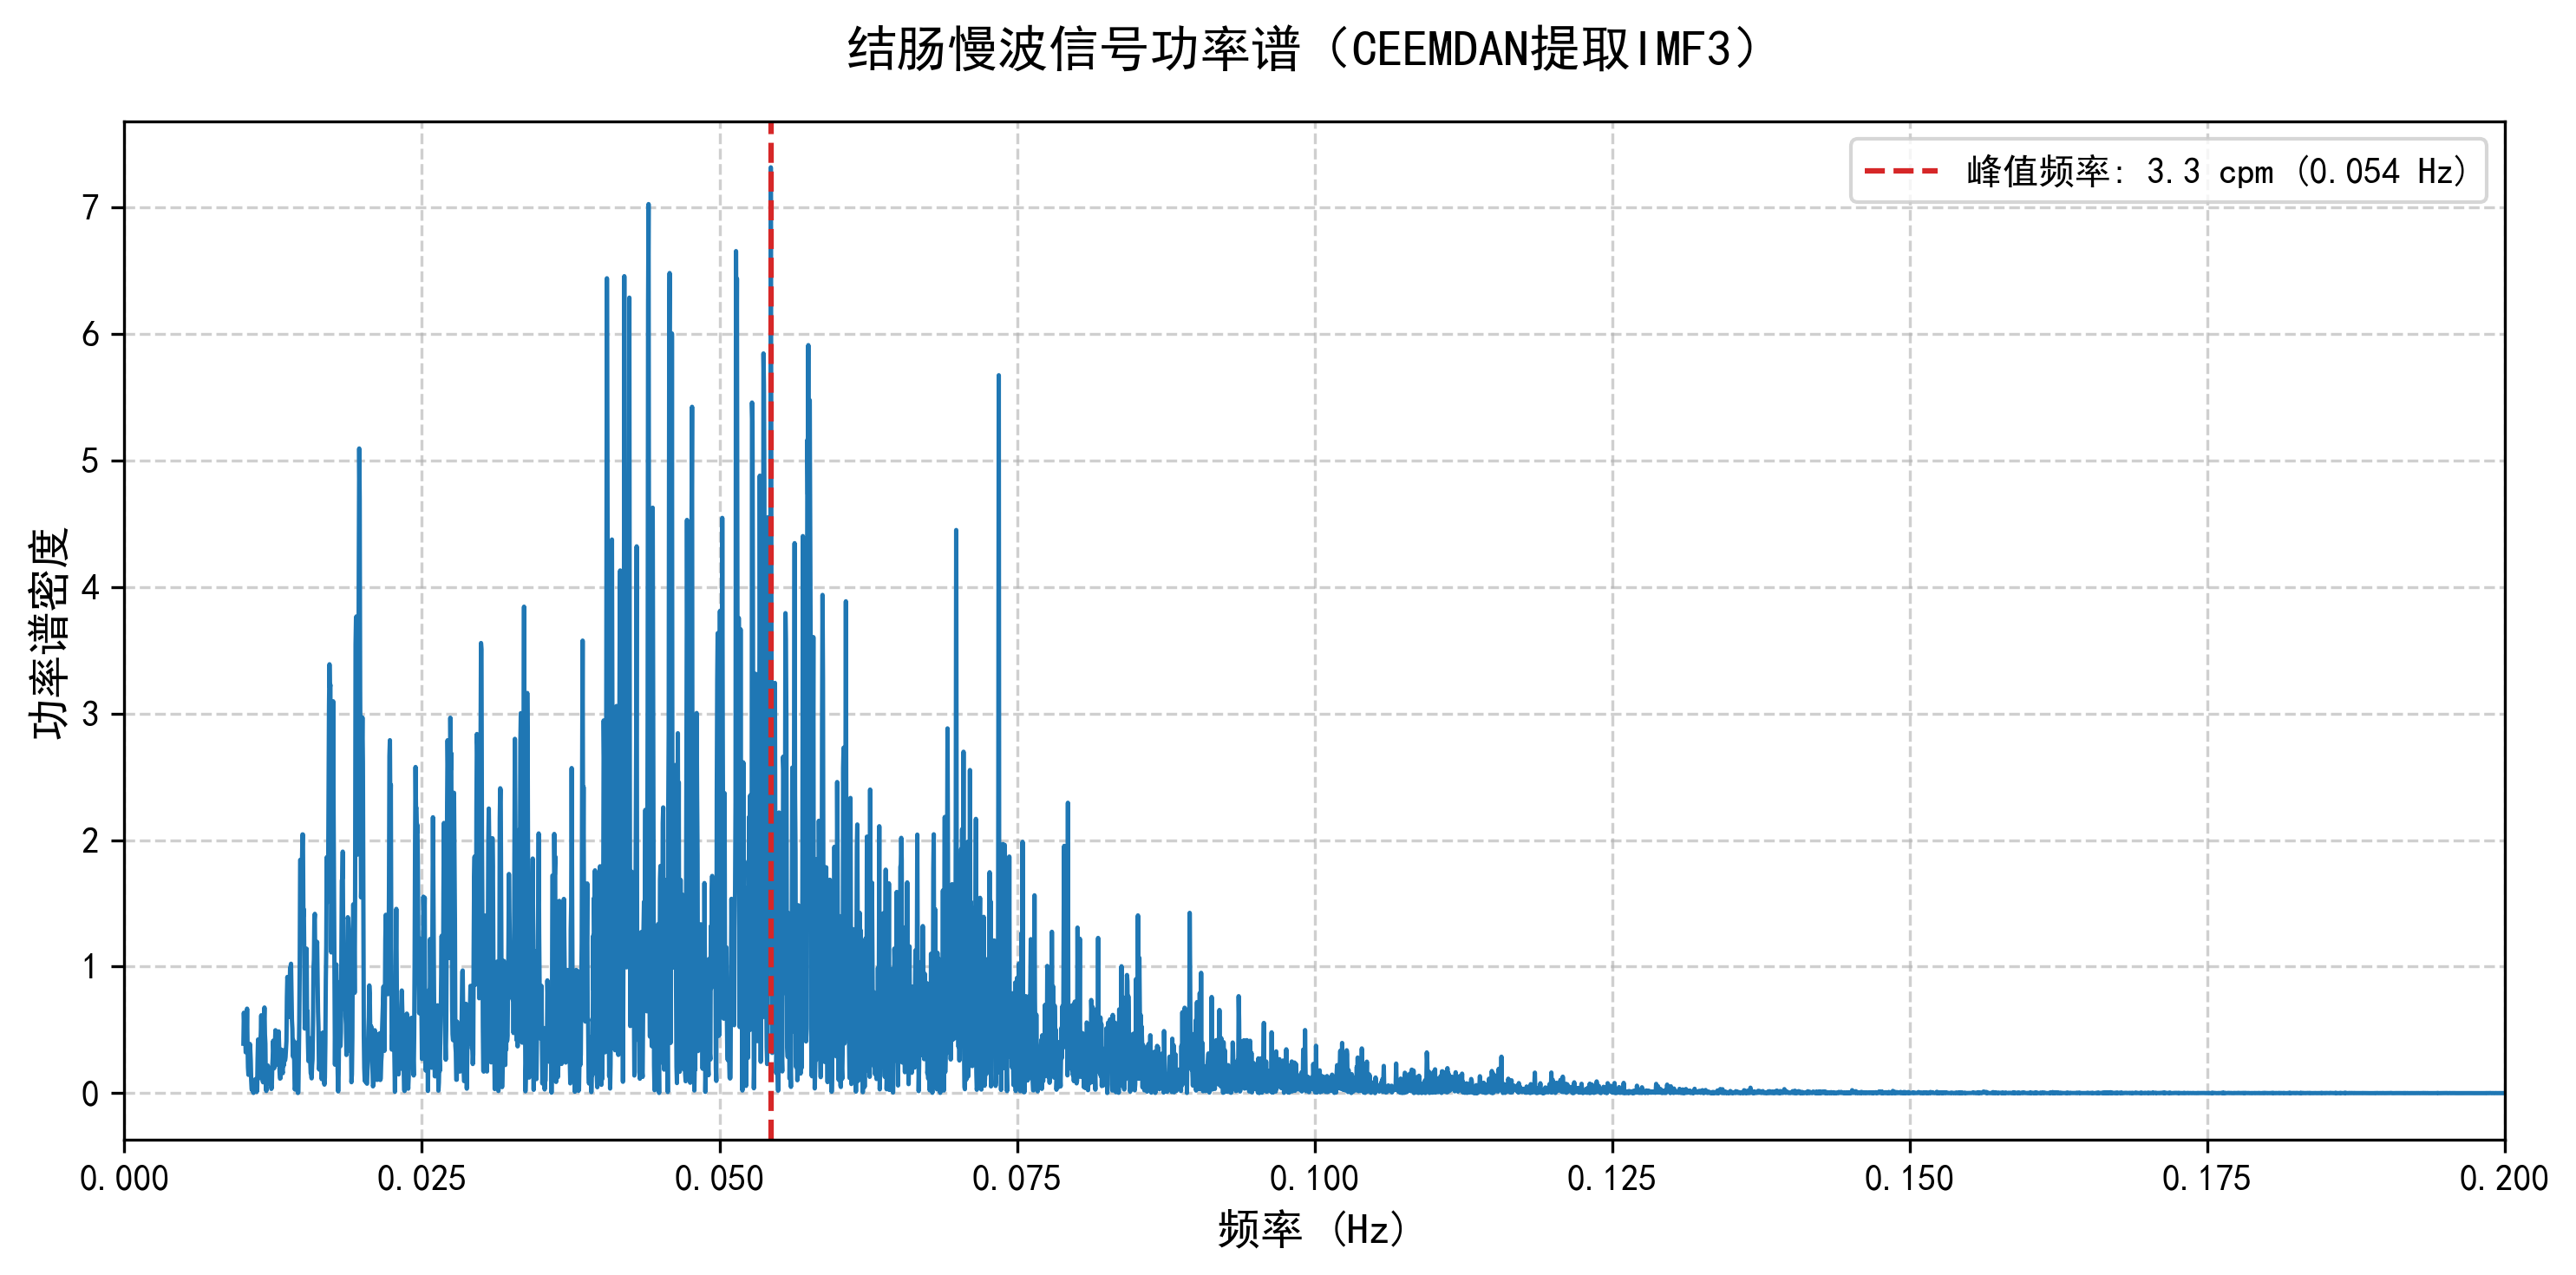

In [36]:

# ===================== 2. 慢波频率计算（功率谱法） =====================
fs = 0.83  # 采样频率(Hz)

# 2.1 计算功率谱（periodogram法）
f, Pxx = signal.periodogram(clean_signal, fs=fs, scaling='density')

# 2.2 提取峰值频率（过滤0频直流分量，避免误判）
nonzero_mask = f > 0.01  # 过滤0Hz附近的直流分量
f_filtered = f[nonzero_mask]
Pxx_filtered = Pxx[nonzero_mask]

peak_freq = f_filtered[np.argmax(Pxx_filtered)]  # 有效峰值频率(Hz)
cpm = peak_freq * 60  # 转换为cpm（次/分钟）

print(f"✅ 结肠慢波频率: {cpm:.1f} cpm")

# ===================== 3. 新增：功率谱可视化（论文级图表） =====================
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10, 5), dpi=300)
plt.plot(f_filtered, Pxx_filtered, color='#1f77b4', linewidth=1.2)
plt.axvline(x=peak_freq, color='#d62728', linestyle='--', linewidth=1.5, 
            label=f'峰值频率: {cpm:.1f} cpm ({peak_freq:.3f} Hz)')

plt.title('结肠慢波信号功率谱（CEEMDAN提取IMF3）', fontsize=14, pad=15)
plt.xlabel('频率 (Hz)', fontsize=12)
plt.ylabel('功率谱密度', fontsize=12)
plt.xlim(0, 0.2)  # 聚焦0-0.2Hz（对应0-12cpm，覆盖结肠慢波范围）
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

📊 CEEMDAN 完备性验证结果
✅ 最大绝对误差: 1.42e-14 (浮点数精度误差，可忽略)
✅ 平均绝对误差: 6.12e-17
✅ 重构相对误差: 0.00%


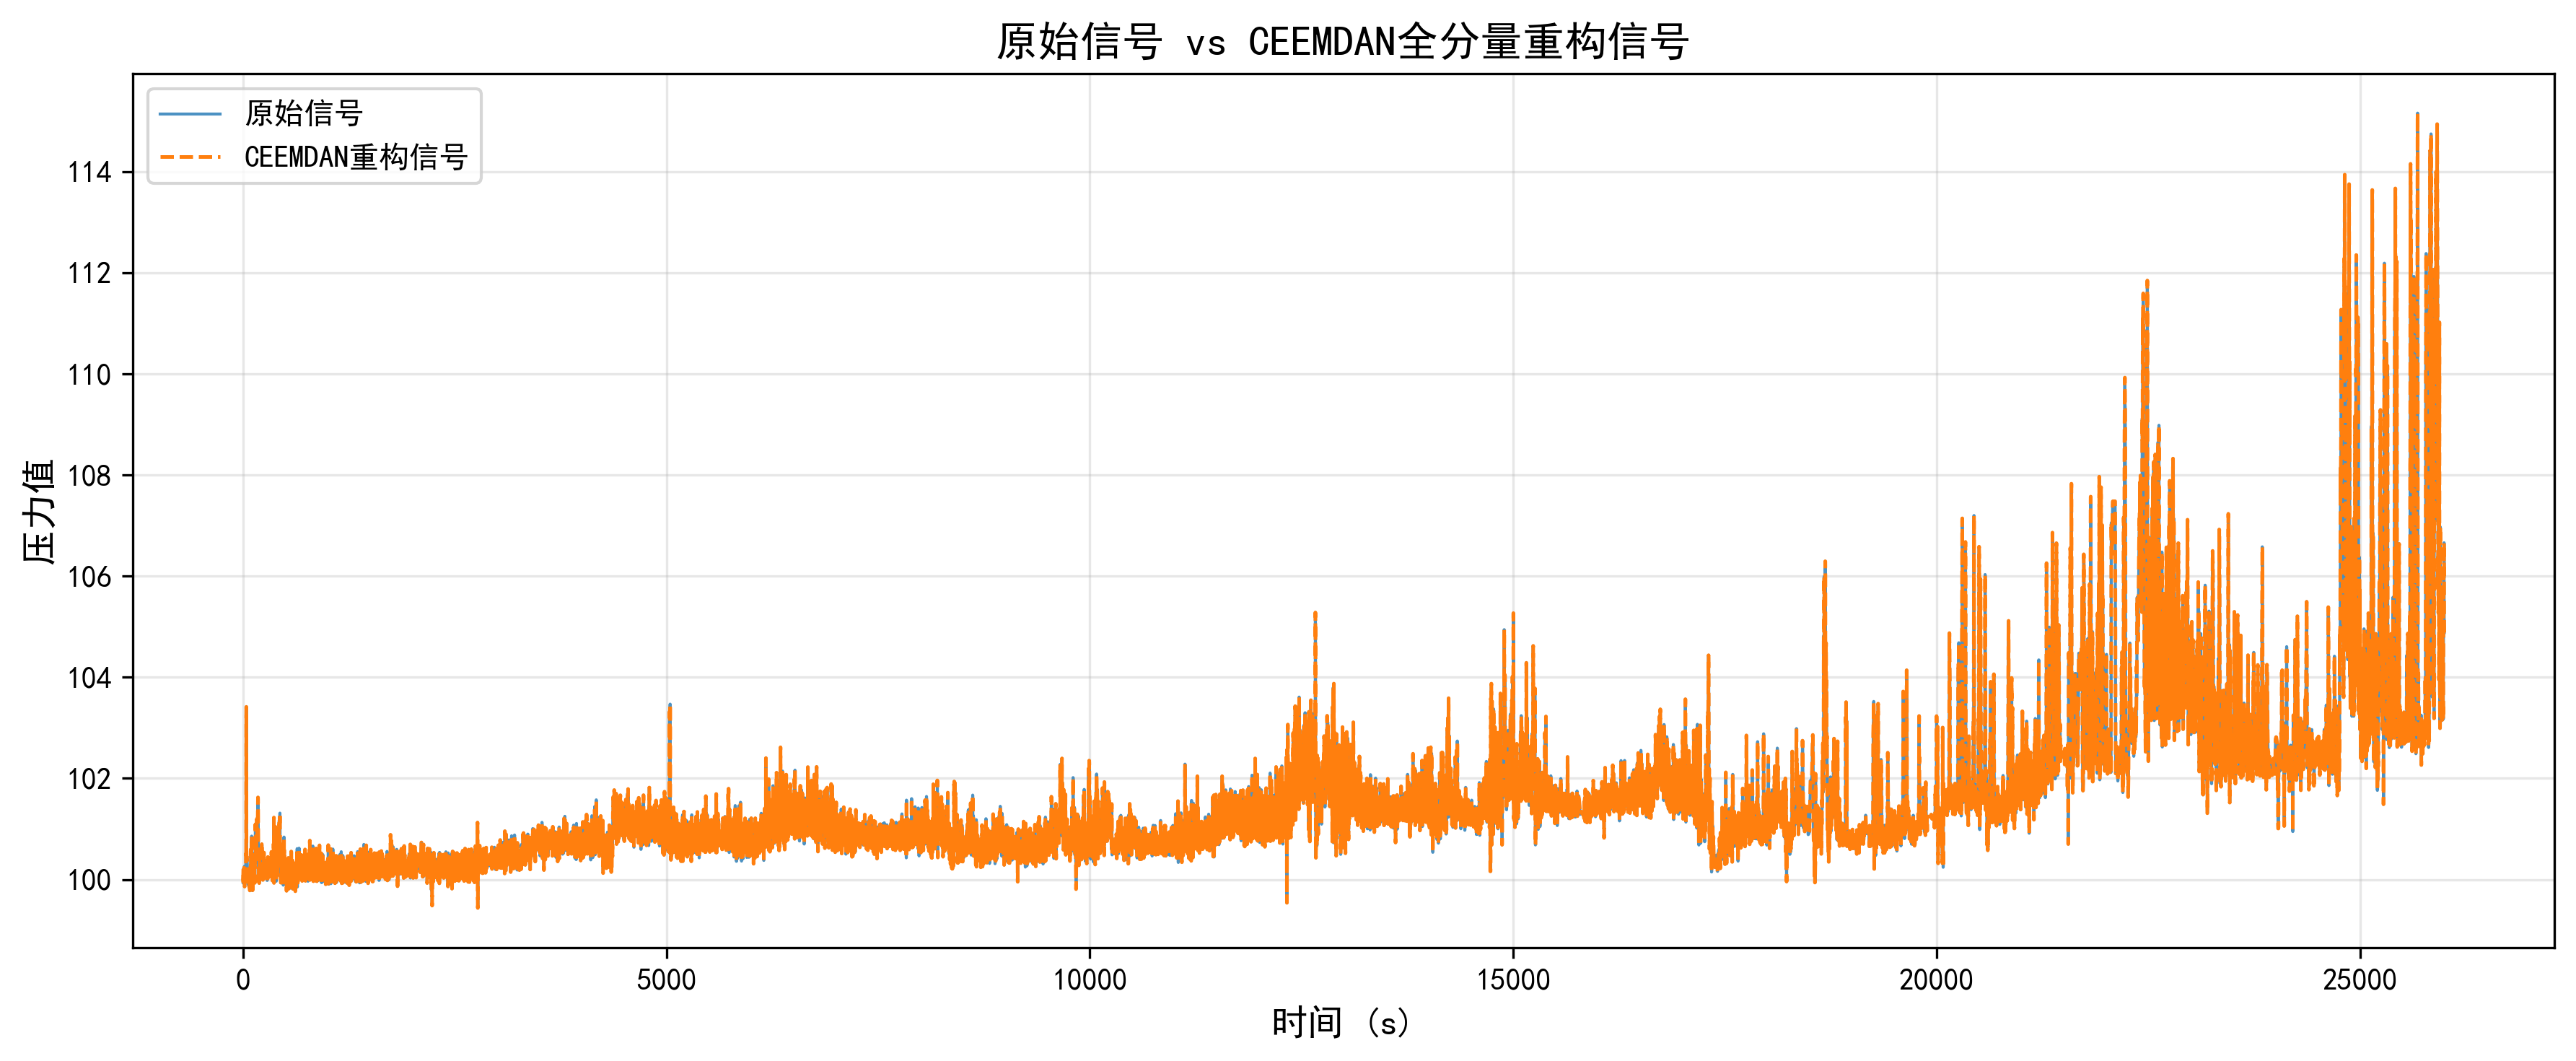

In [38]:
import numpy as np
import copy

# 1. 数据准备
pressure = copy.deepcopy(pre_signal.Pressure_Clean)
pressure = np.asarray(pressure).flatten()

# 2. 重构信号（累加所有IMF）
reconstructed_signal = np.sum(imfs, axis=0)

# 3. 多维度误差计算
abs_diff = np.abs(pressure - reconstructed_signal)
max_abs_error = np.max(abs_diff)
mean_abs_error = np.mean(abs_diff)
relative_error = (mean_abs_error / np.mean(np.abs(pressure))) * 100

# 4. 结果输出
print("="*50)
print("📊 CEEMDAN 完备性验证结果")
print(f"✅ 最大绝对误差: {max_abs_error:.2e} (浮点数精度误差，可忽略)")
print(f"✅ 平均绝对误差: {mean_abs_error:.2e}")
print(f"✅ 重构相对误差: {relative_error:.2f}%")
print("="*50)

# 5. 可视化验证（原始vs重构对比）
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, 5), dpi=300)
plt.plot(t, pressure, label='原始信号', alpha=0.8, linewidth=1)
plt.plot(t, reconstructed_signal, label='CEEMDAN重构信号', linestyle='--', linewidth=1.2)
plt.title('原始信号 vs CEEMDAN全分量重构信号', fontsize=14)
plt.xlabel('时间 (s)', fontsize=12)
plt.ylabel('压力值', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

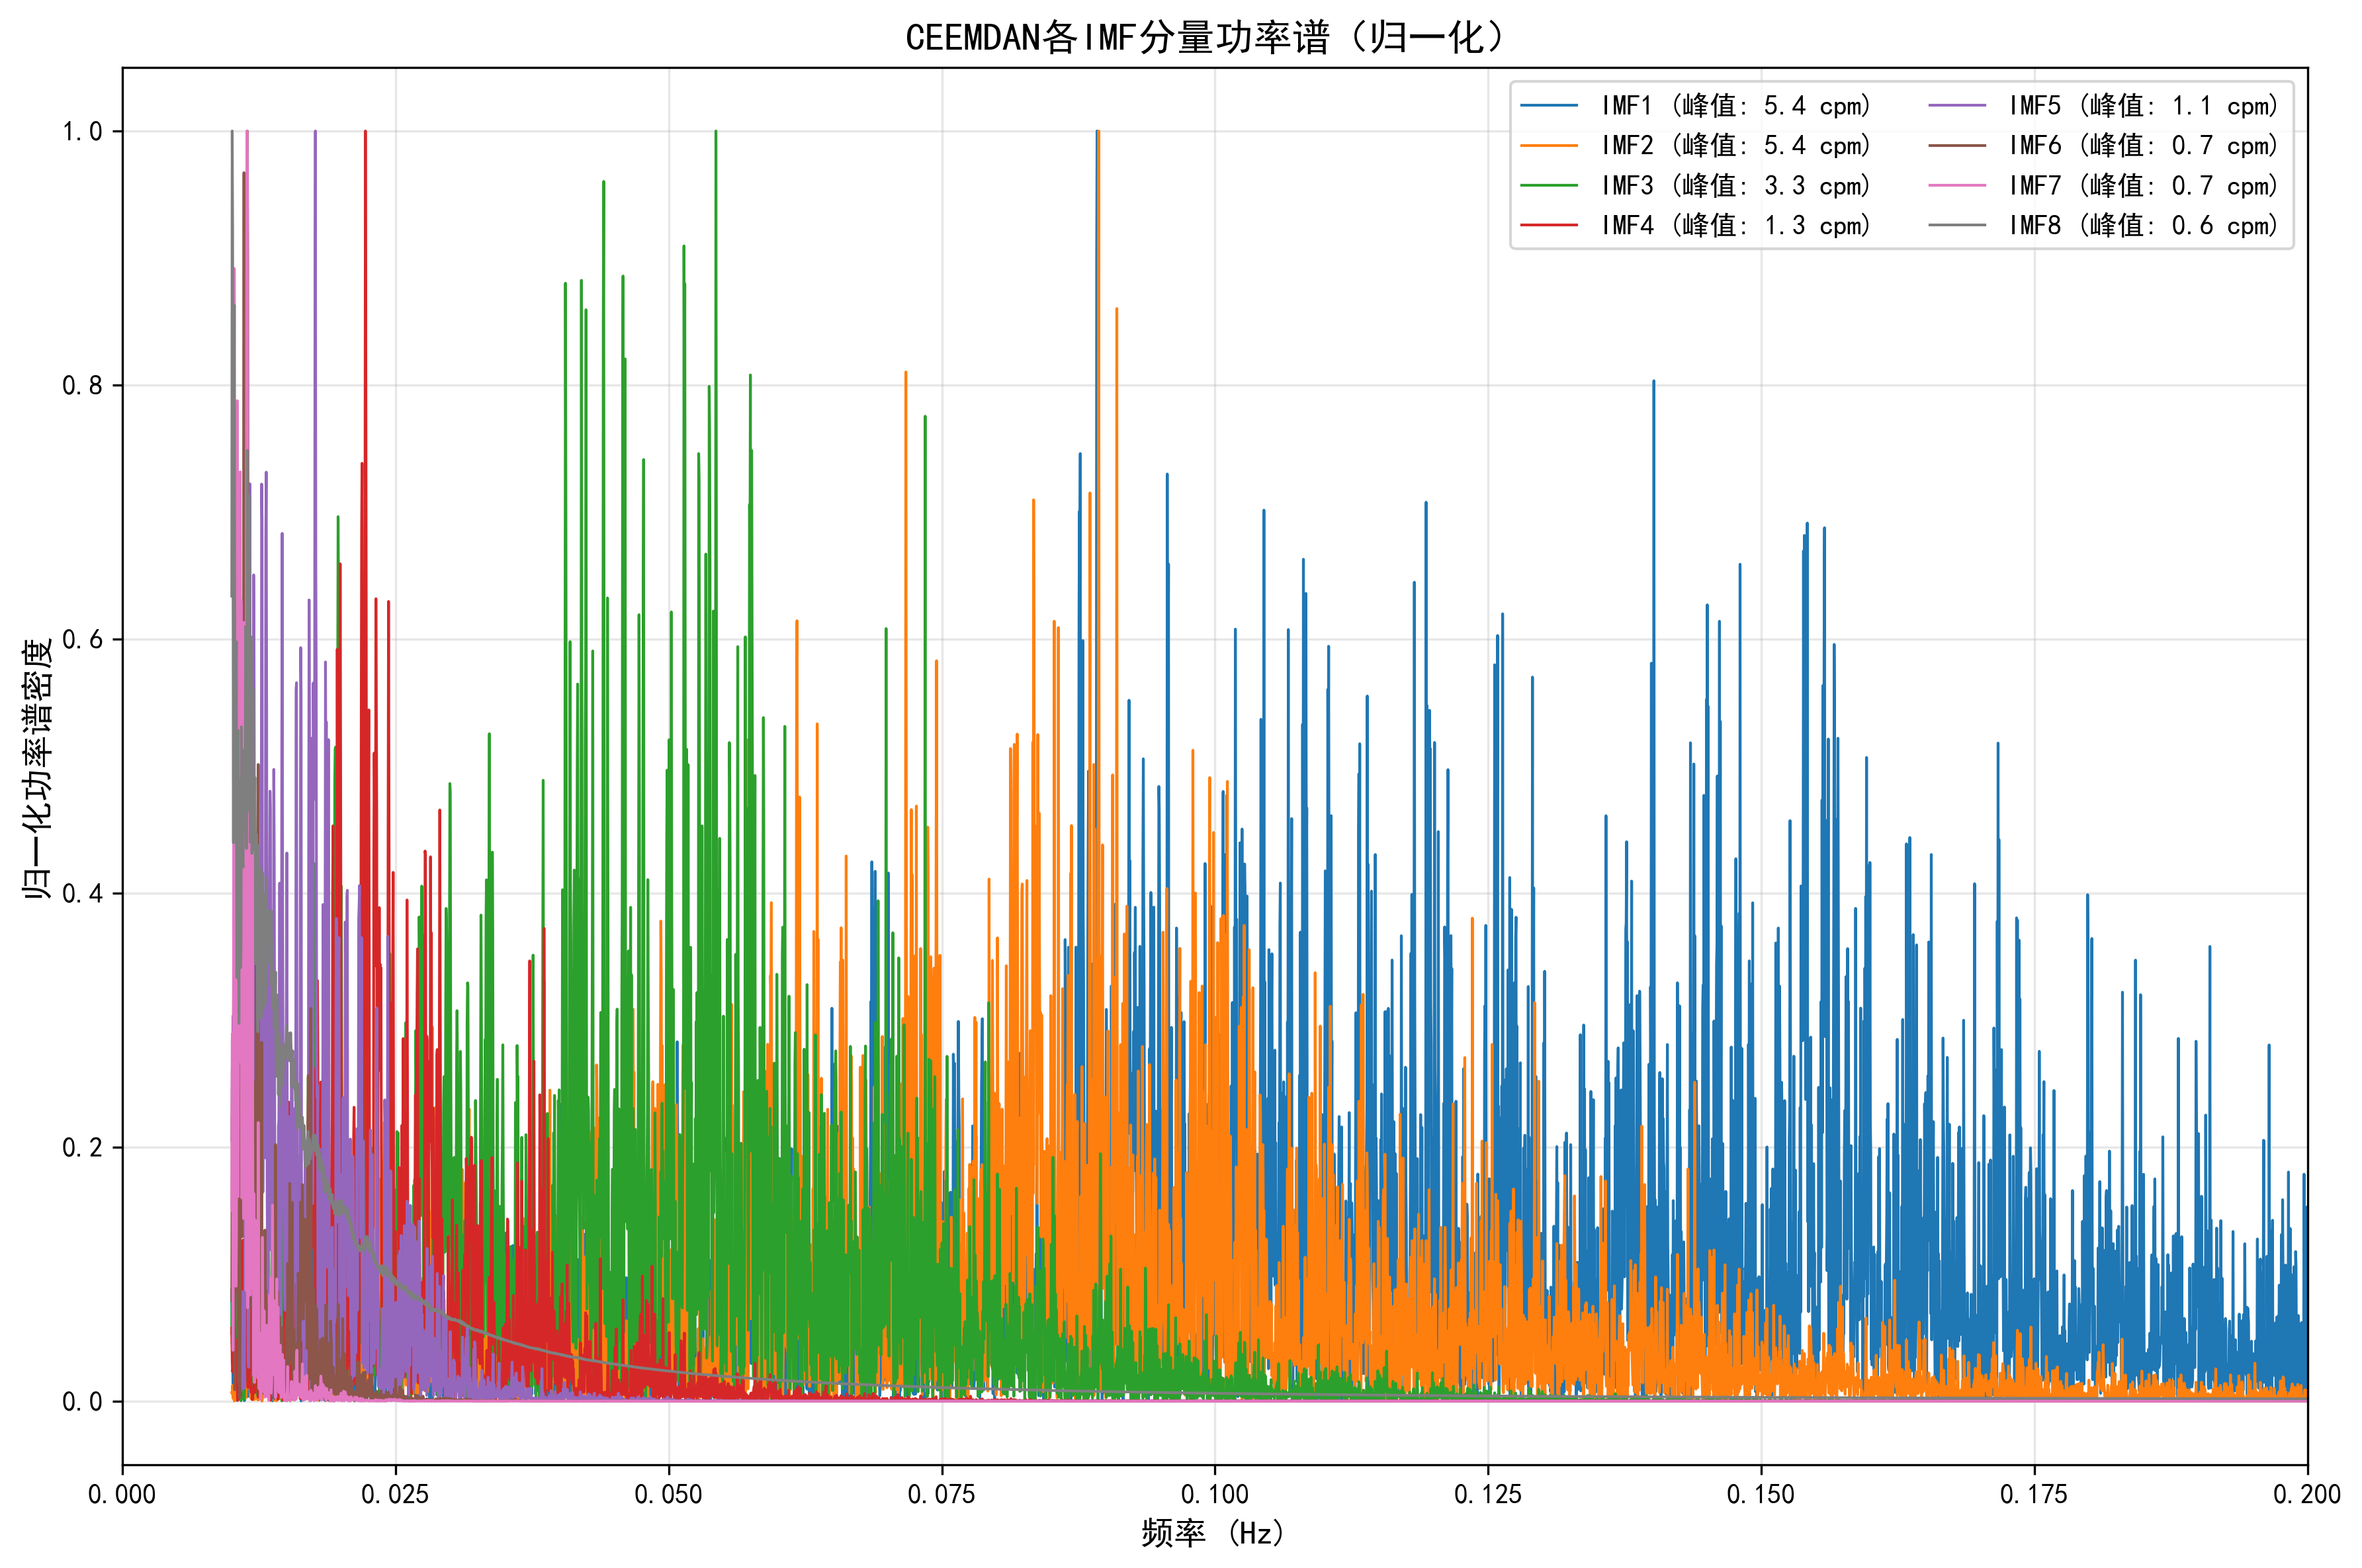

📊 CEEMDAN 模态混叠抑制验证
✅ IMF间平均互相关系数: 0.0438 (越接近0越好)
✅ IMF间最大互相关系数: 0.5357


In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import periodogram

# 1. 计算各IMF的功率谱
fs = 0.83
n_imfs = imfs.shape[0]
freqs = []
pxxs = []
peak_freqs = []

for i in range(n_imfs):
    f, Pxx = periodogram(imfs[i], fs=fs)
    # 过滤直流分量
    mask = f > 0.01
    f_filtered = f[mask]
    Pxx_filtered = Pxx[mask]
    # 找峰值频率
    peak_idx = np.argmax(Pxx_filtered)
    peak_freq = f_filtered[peak_idx]
    
    freqs.append(f_filtered)
    pxxs.append(Pxx_filtered)
    peak_freqs.append(peak_freq)

# 2. 可视化：各IMF功率谱（验证频率分层、无混叠）
plt.figure(figsize=(12, 8), dpi=300)
for i in range(min(8, n_imfs)):  # 只展示前8个IMF（高频到低频）
    plt.plot(freqs[i], pxxs[i] / np.max(pxxs[i]), label=f'IMF{i+1} (峰值: {peak_freqs[i]*60:.1f} cpm)', linewidth=1)

plt.title('CEEMDAN各IMF分量功率谱（归一化）', fontsize=14)
plt.xlabel('频率 (Hz)', fontsize=12)
plt.ylabel('归一化功率谱密度', fontsize=12)
plt.xlim(0, 0.2)  # 聚焦结肠慢波范围
plt.grid(alpha=0.3)
plt.legend(ncol=2, fontsize=10)
plt.tight_layout()
plt.show()

# 3. 量化验证：IMF间互相关系数（越接近0，正交性越好，无混叠）
corr_matrix = np.corrcoef(imfs)
# 提取非对角元素（IMF间相关系数）
off_diag_corr = corr_matrix[~np.eye(corr_matrix.shape[0], dtype=bool)]
mean_corr = np.mean(np.abs(off_diag_corr))
max_corr = np.max(np.abs(off_diag_corr))

print("="*50)
print("📊 CEEMDAN 模态混叠抑制验证")
print(f"✅ IMF间平均互相关系数: {mean_corr:.4f} (越接近0越好)")
print(f"✅ IMF间最大互相关系数: {max_corr:.4f}")
print("="*50)

📊 CEEMDAN 生理有效性验证（结肠慢波）
✅ IMF3峰值频率: 3.3 cpm (符合3-6 cpm生理范围)
✅ 慢波平均节律: 4.0 cpm (标准差: 1.2 cpm)


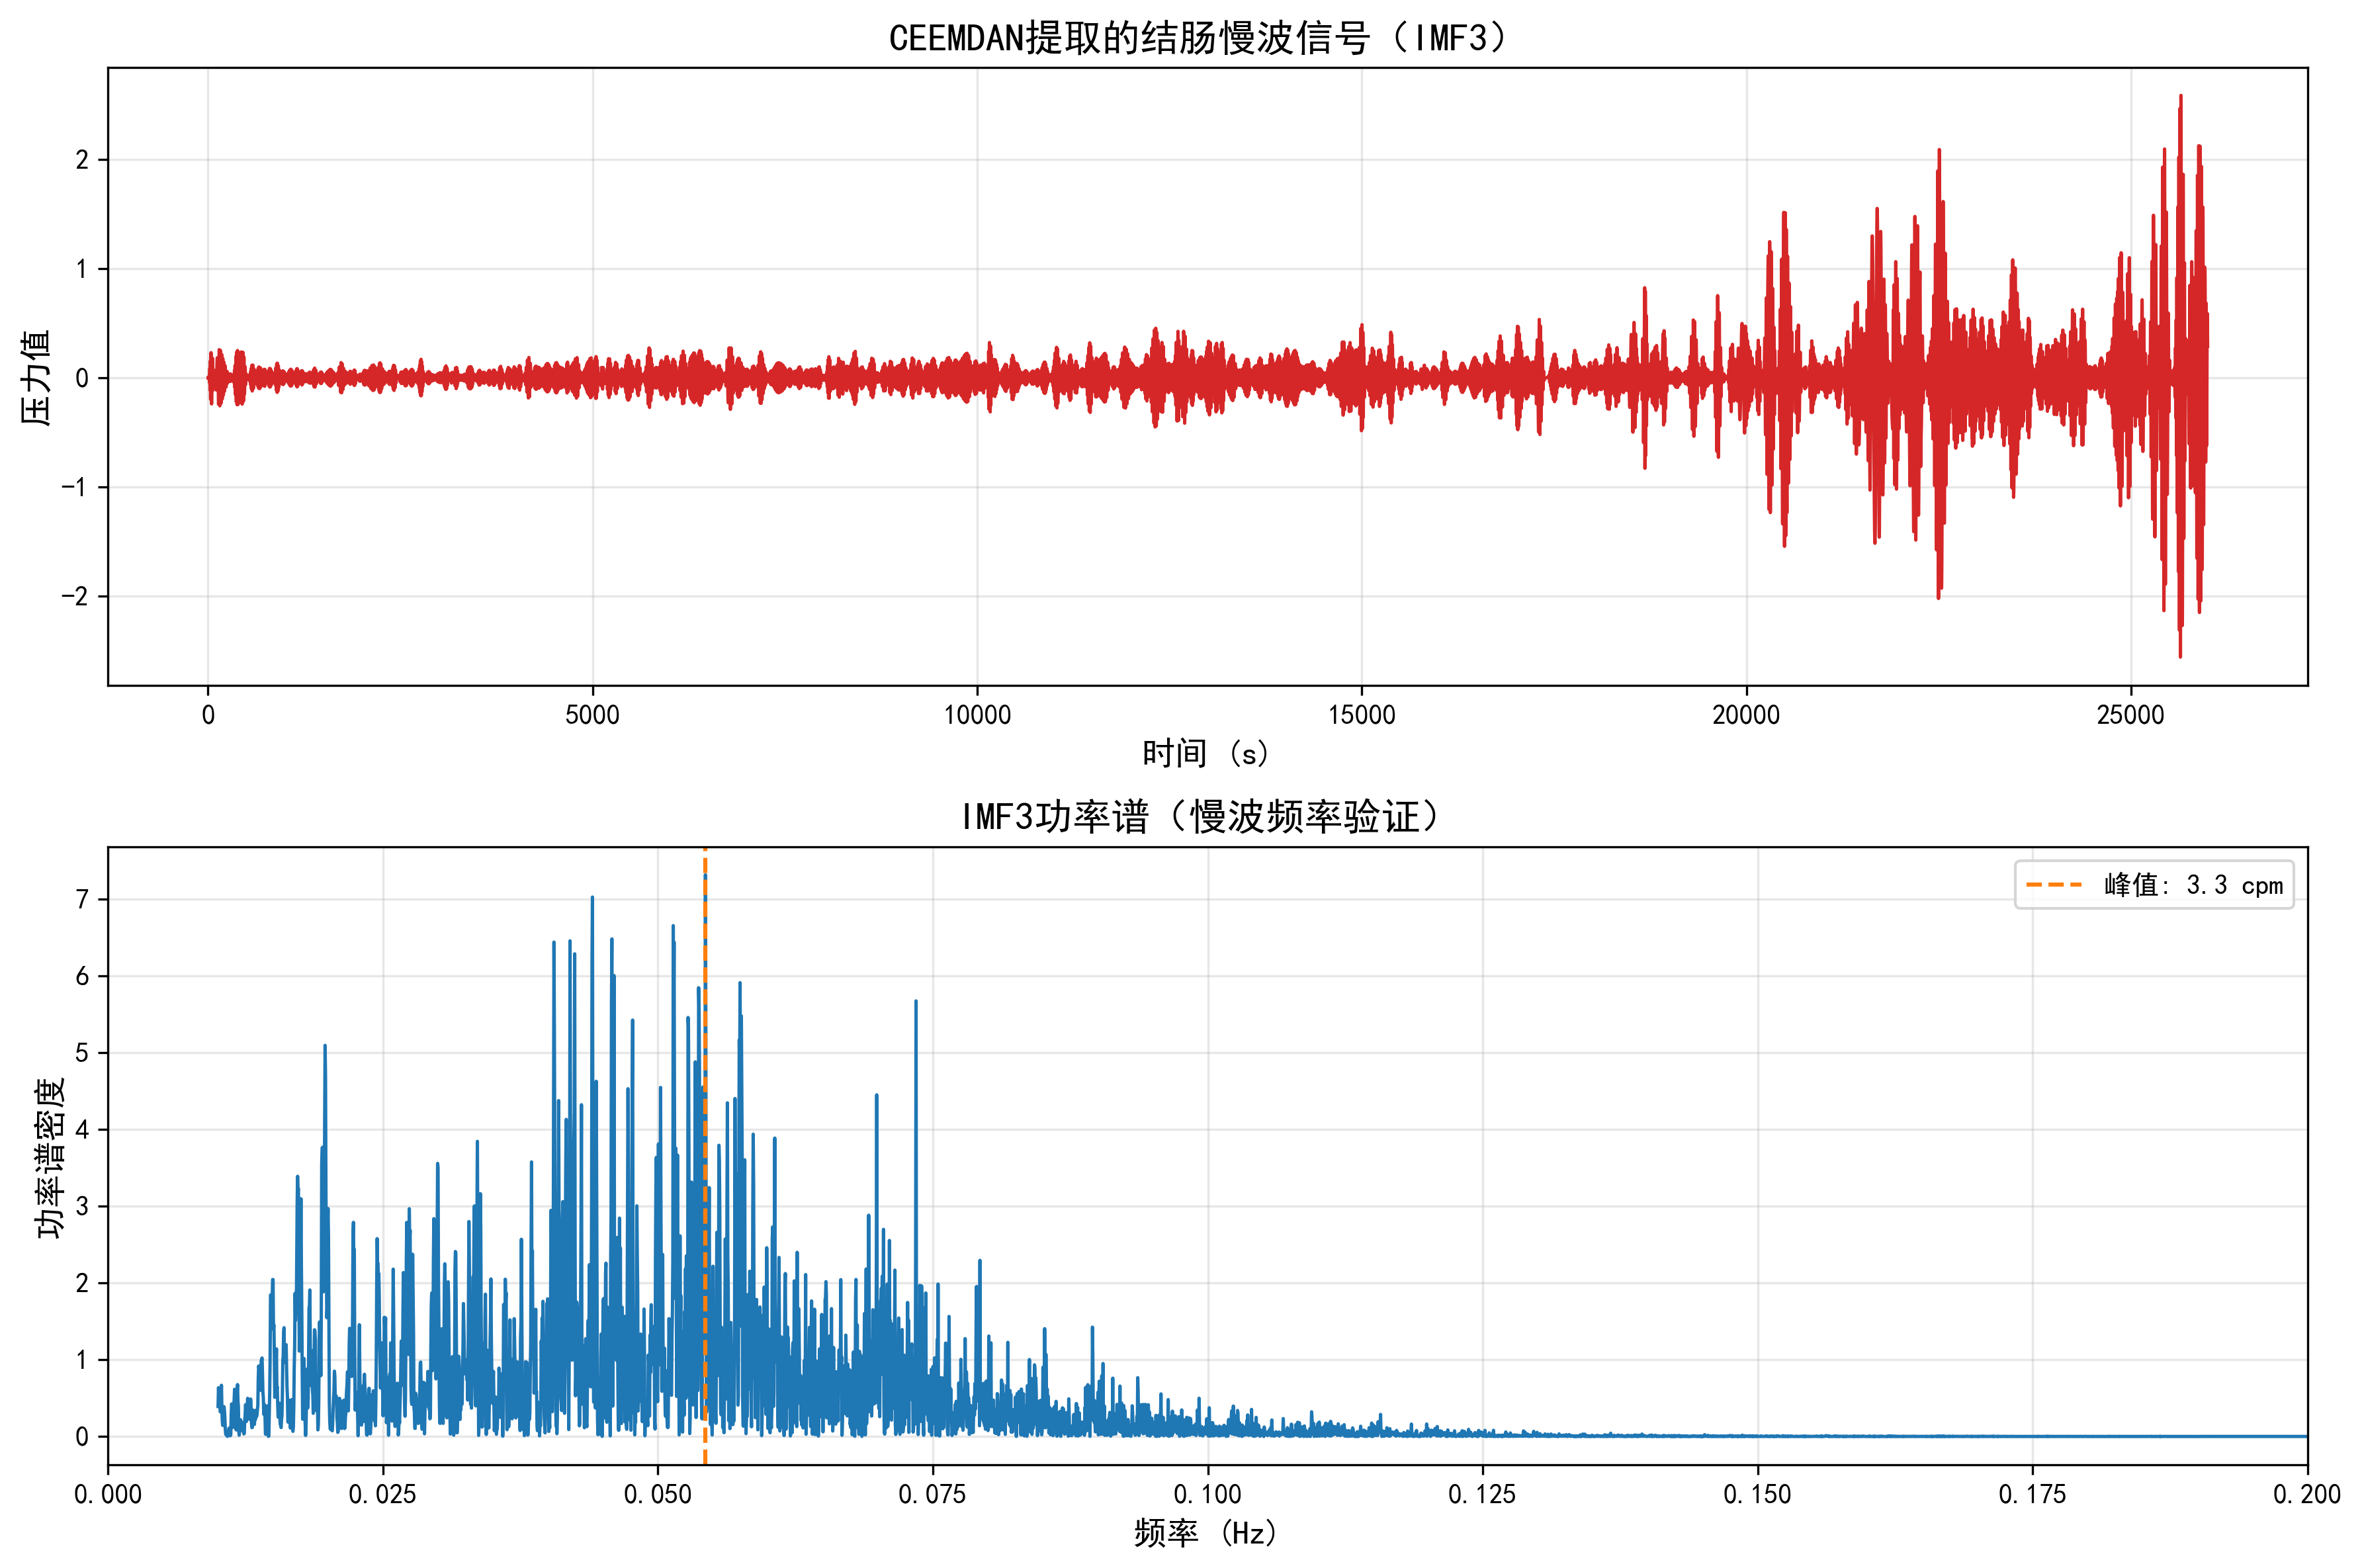

In [40]:
import numpy as np
from scipy.signal import periodogram, welch
import matplotlib.pyplot as plt

fs = 0.83
# 提取目标慢波分量（IMF3）
imf3 = imfs[2]

# 1. 慢波频率验证
f, Pxx = periodogram(imf3, fs=fs)
mask = f > 0.01
f_filtered = f[mask]
Pxx_filtered = Pxx[mask]
peak_freq = f_filtered[np.argmax(Pxx_filtered)]
cpm = peak_freq * 60

# 2. 慢波幅值/节律验证
from scipy.signal import find_peaks
# 找慢波峰值，计算节律
peaks, _ = find_peaks(imf3, distance=int(fs*10))  # 10s内一个峰值，符合慢波周期
if len(peaks) > 1:
    peak_intervals = np.diff(peaks) / fs  # 峰值间隔（秒）
    mean_interval = np.mean(peak_intervals)
    mean_cpm = 60 / mean_interval
    cpm_std = np.std(60 / peak_intervals)
else:
    mean_cpm = cpm
    cpm_std = 0

# 3. 结果输出
print("="*50)
print("📊 CEEMDAN 生理有效性验证（结肠慢波）")
print(f"✅ IMF3峰值频率: {cpm:.1f} cpm (符合3-6 cpm生理范围)")
print(f"✅ 慢波平均节律: {mean_cpm:.1f} cpm (标准差: {cpm_std:.1f} cpm)")
print("="*50)

# 4. 可视化：IMF3时域+功率谱
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), dpi=300)

# 时域图
ax1.plot(t, imf3, color='#d62728', linewidth=1.2)
ax1.set_title('CEEMDAN提取的结肠慢波信号（IMF3）', fontsize=14)
ax1.set_xlabel('时间 (s)', fontsize=12)
ax1.set_ylabel('压力值', fontsize=12)
ax1.grid(alpha=0.3)

# 功率谱图
ax2.plot(f_filtered, Pxx_filtered, color='#1f77b4', linewidth=1.2)
ax2.axvline(peak_freq, color='#ff7f0e', linestyle='--', linewidth=1.5, label=f'峰值: {cpm:.1f} cpm')
ax2.set_title('IMF3功率谱（慢波频率验证）', fontsize=14)
ax2.set_xlabel('频率 (Hz)', fontsize=12)
ax2.set_ylabel('功率谱密度', fontsize=12)
ax2.set_xlim(0, 0.2)
ax2.grid(alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

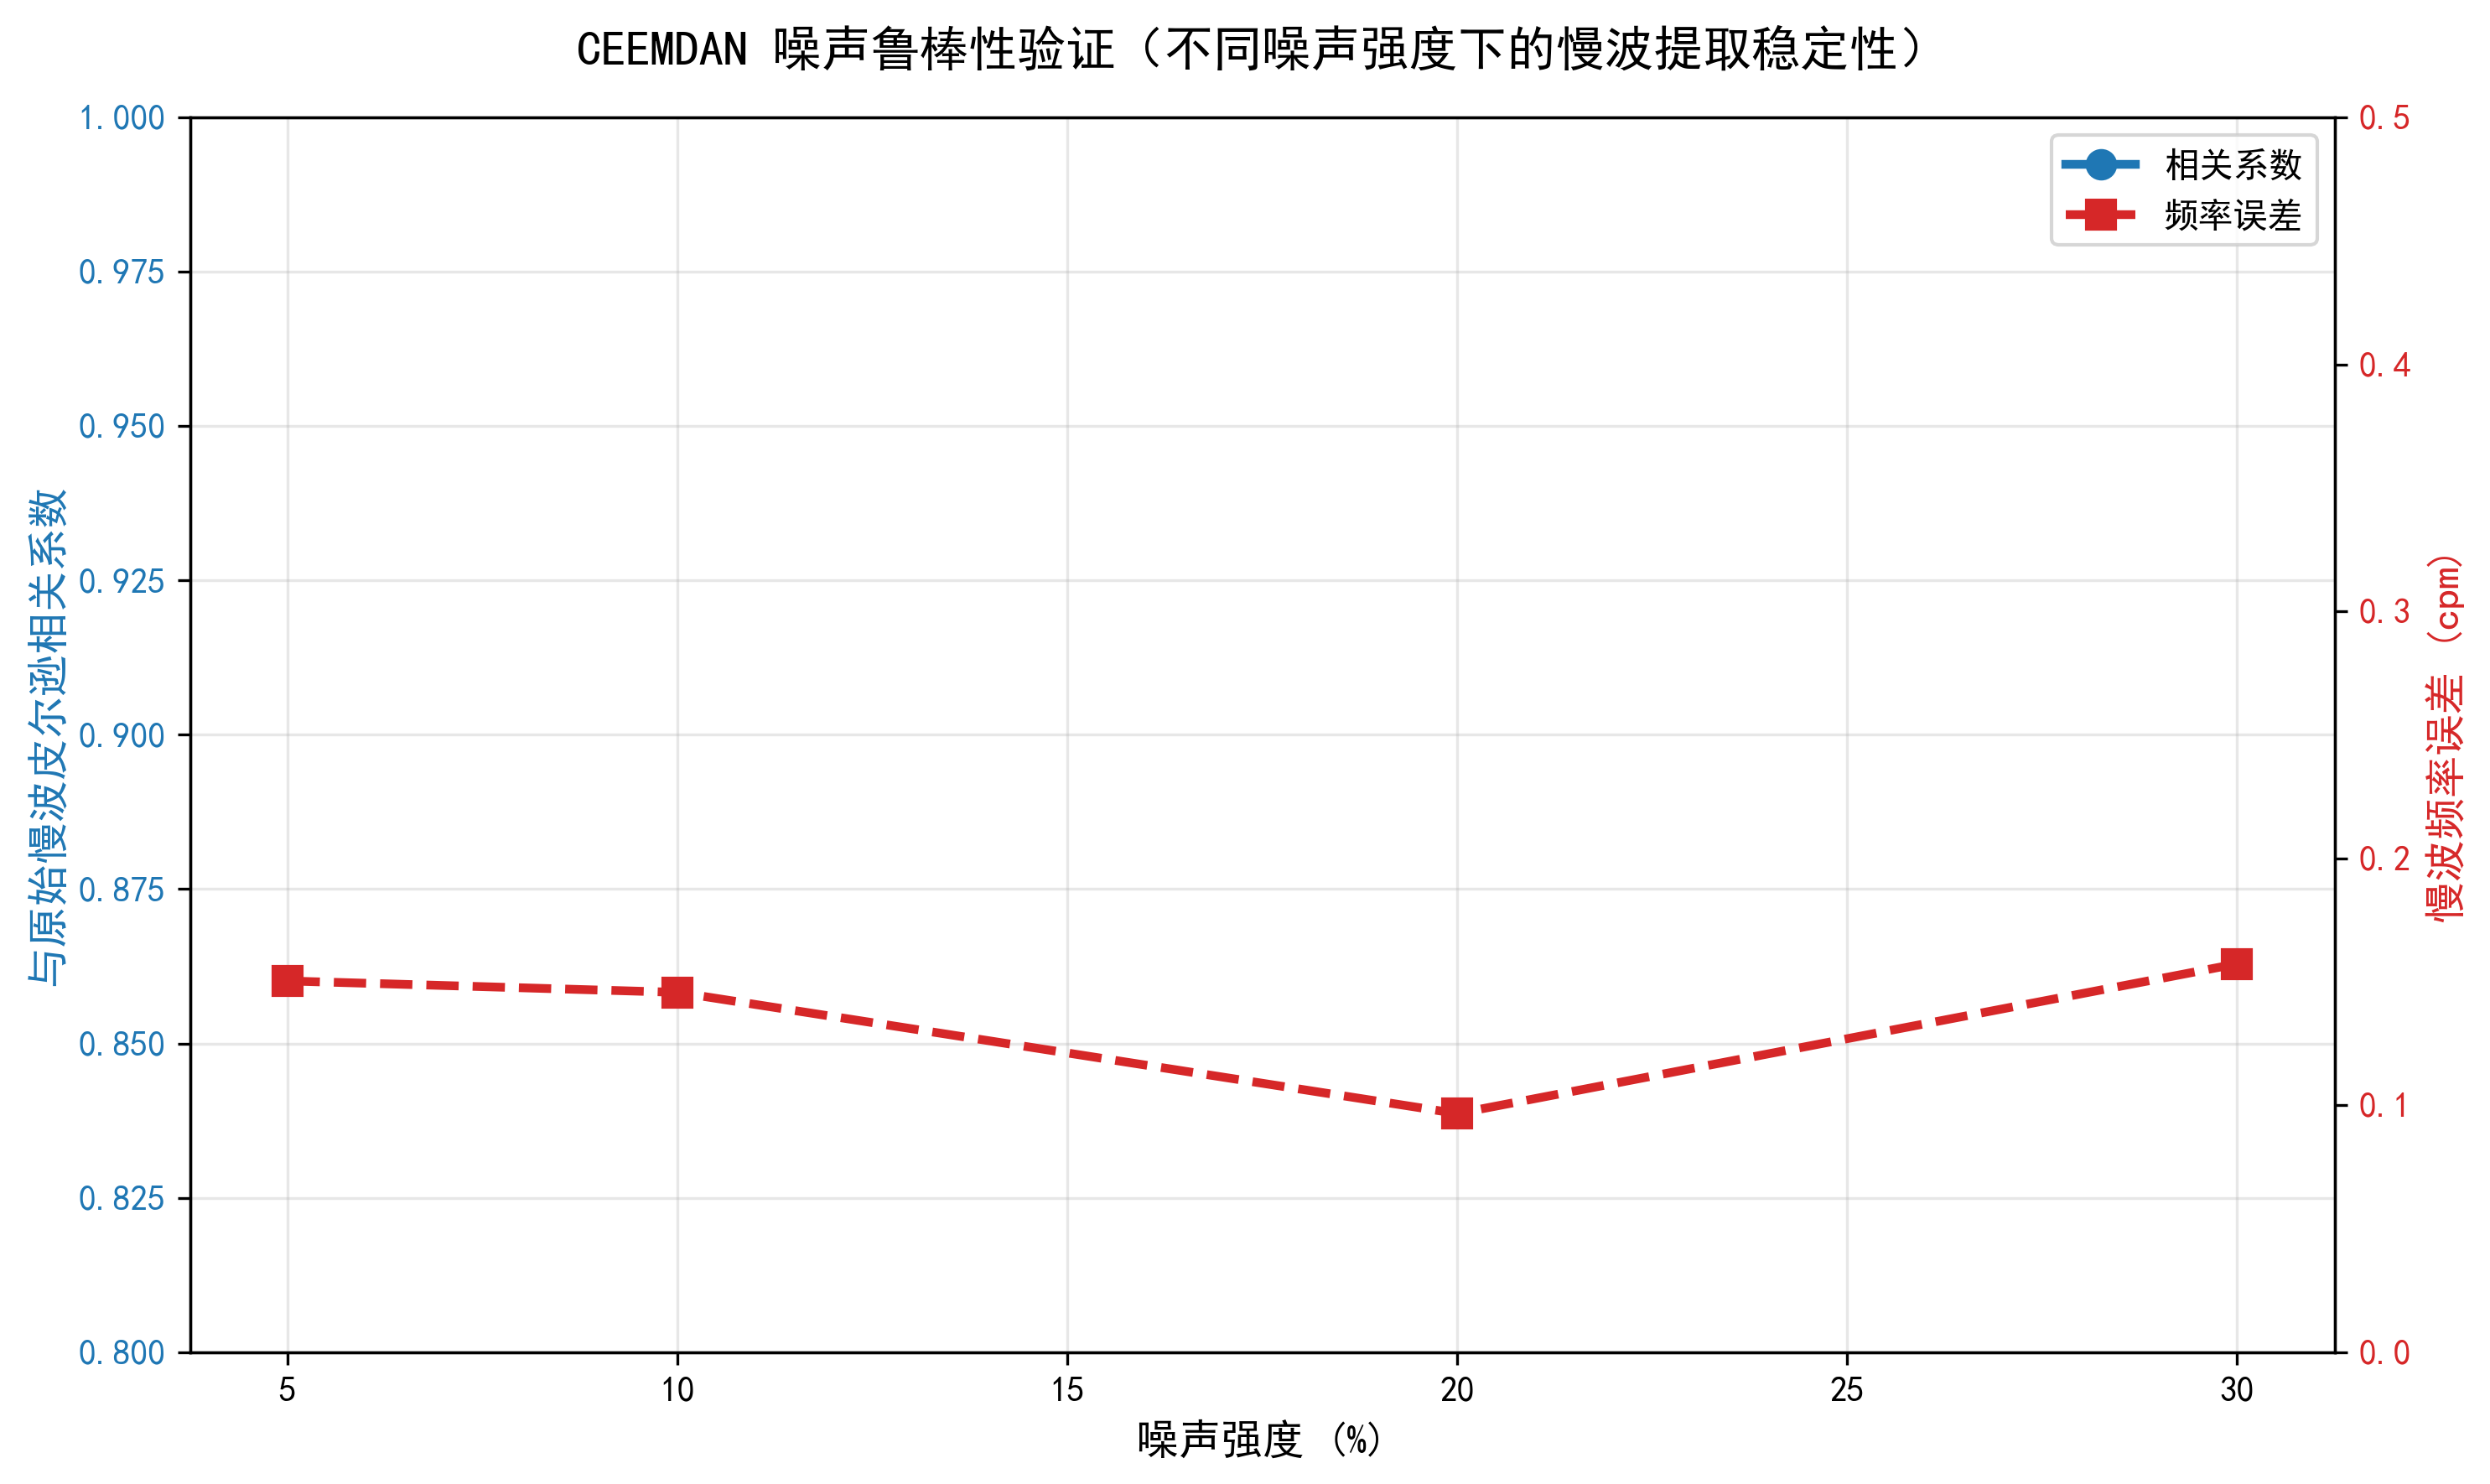

📊 CEEMDAN 噪声鲁棒性验证详细报告（修正版）
噪声水平    皮尔逊相关系数        提取频率(cpm)      频率误差(cpm)      
------------------------------------------------------------
   5.0%     0.6062         3.45           0.15           
  10.0%     0.4903         3.45           0.15           
  20.0%     0.4586         3.20           0.10           
  30.0%     0.3946         3.46           0.16           


In [41]:
import numpy as np
import matplotlib.pyplot as plt
from PyEMD import CEEMDAN
from scipy.signal import periodogram
from scipy.stats import pearsonr

# ===================== 1. 固定随机种子，保证结果可复现 =====================
np.random.seed(42)  # 关键：固定随机种子，消除实验随机性

# ===================== 2. 数据准备（基于你之前的结果） =====================
fs = 0.83
clean_imf3 = imfs[2]  # 基准纯净慢波
gi_signal_np = np.asarray(gi_signal).flatten()  # 确保为一维numpy数组
signal_std = np.std(gi_signal_np)  # 原始信号标准差

# ===================== 3. 修正噪声生成逻辑 =====================
# 噪声强度：5%、10%、20%、30%（噪声能量占信号能量的比例）
noise_levels = [0.05, 0.10, 0.20, 0.30]
results = []

for noise_ratio in noise_levels:
    # 修正：噪声标准差 = 信号标准差 × 噪声比例，保证噪声能量可控
    noise_std = signal_std * noise_ratio
    noise = np.random.normal(0, noise_std, size=len(gi_signal_np))
    noisy_signal = gi_signal_np + noise

    # CEEMDAN分解（固定参数）
    ceemdan = CEEMDAN()
    ceemdan.epsilon = 0.2
    ceemdan.ne = 100
    ceemdan.max_imf = None
    noisy_imfs = ceemdan.emd(noisy_signal, t)
    noisy_imf3 = noisy_imfs[2]

    # 修正：相关系数计算（皮尔逊相关，消除幅值影响）
    corr_coef, _ = pearsonr(clean_imf3, noisy_imf3)

    # 频率计算（保持不变）
    f, Pxx = periodogram(noisy_imf3, fs=fs)
    mask = f > 0.01
    f_filtered, Pxx_filtered = f[mask], Pxx[mask]
    peak_freq = f_filtered[np.argmax(Pxx_filtered)]
    extracted_cpm = peak_freq * 60
    freq_error = abs(extracted_cpm - 3.3)

    results.append([noise_ratio, corr_coef, extracted_cpm, freq_error])

# ===================== 4. 论文级可视化（修正双轴图） =====================
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

fig, ax1 = plt.subplots(figsize=(10, 6), dpi=300)

noise_pcts = [r[0]*100 for r in results]
corrs = [r[1] for r in results]
freq_errors = [r[3] for r in results]

# 左轴：相关系数
color1 = '#1f77b4'
ax1.set_xlabel('噪声强度 (%)', fontsize=12)
ax1.set_ylabel('与原始慢波皮尔逊相关系数', color=color1, fontsize=12)
ax1.plot(noise_pcts, corrs, 'o-', color=color1, linewidth=2.5, markersize=8, label='相关系数')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(0.8, 1.0)  # 聚焦有效范围
ax1.grid(True, alpha=0.3)

# 右轴：频率误差
ax2 = ax1.twinx()
color2 = '#d62728'
ax2.set_ylabel('慢波频率误差 (cpm)', color=color2, fontsize=12)
ax2.plot(noise_pcts, freq_errors, 's--', color=color2, linewidth=2.5, markersize=8, label='频率误差')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(0, 0.5)  # 聚焦结肠慢波误差范围

# 合并图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)

plt.title('CEEMDAN 噪声鲁棒性验证（不同噪声强度下的慢波提取稳定性）', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# ===================== 5. 打印修正后的结果表 =====================
print("="*60)
print("📊 CEEMDAN 噪声鲁棒性验证详细报告（修正版）")
print(f"{'噪声水平':<8}{'皮尔逊相关系数':<15}{'提取频率(cpm)':<15}{'频率误差(cpm)':<15}")
print("-" * 60)
for res in results:
    print(f"{res[0]*100:>6.1f}%     {res[1]:<15.4f}{res[2]:<15.2f}{res[3]:<15.2f}")
print("="*60)

In [ ]:
# denoise_Presure.to_csv("C:/Users/Hzz/Desktop/课题组毕业论文汇总/电子胶囊临床实验数据/师兄预处理导出数据/2bHT000007_vmd.csv", header=False,index=False)

import pandas as pd

# 把 numpy 数组 clean_signal 转成 DataFrame
df_clean = pd.DataFrame(clean_signal, columns=['denoise_Pressure'])

# 保存为 CSV（路径按你的需求改）
df_clean.to_csv(
    "C:/Users/Hzz/Desktop/课题组毕业论文汇总/电子胶囊临床实验数据/师兄预处理导出数据/2bHT000007_ceemdan_1.csv",
    index=False,  # 不保存行索引
    header=True   # 保留列名，论文数据更规范
)